# llama3.1:8b — Current Results

A focused look at one model across two extractors, under the current pipeline:

- de-duplicated system prompt
- pdfplumber line merging enabled
- **all 10 samples scored** (samples 1 and 2 no longer held out)
- Path B rules from `data/input/Rules.xlsx`

> Samples 1 and 2 informed the prompt, so these scores are optimistic and are not a clean
> estimate of performance on unseen documents. They are included because they hold 16 of the
> 22 `question.text` gold items — without them that label cannot be measured at all.

## Setup

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old,
    micro_prf1, compute_f1_rows, confusion_matrix_df,
)
from dmpbridge.evaluation.annotation_rules import convert_tag_to_final, load_method_new
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MODEL   = "llama3.1:8b"
RUNS    = [("pdfplumber", "llama3.1-8b_pdfplumber_whole_doc"),
           ("docling",    "llama3.1-8b_docling_whole_doc")]
EXCLUDE = []          # all 10 samples
COLORS  = {"pdfplumber": "#1d4ed8", "docling": "#34d399"}

results = {}
for name, tag in RUNS:
    df_a, conf_a, err_a = load_method_old(tag, exclude=EXCLUDE)
    if df_a is None:
        print(f"{name:12s}: no output found — run dmpbridge-wholedoc first")
        continue
    convert_tag_to_final(tag)
    df_b, conf_b, err_b = load_method_new(tag, exclude=EXCLUDE)
    results[name] = {"A": (df_a, conf_a, err_a), "B": (df_b, conf_b, err_b), "tag": tag}
    print(f"{name:12s}: loaded ({len(df_a)} samples)")

pdfplumber  : loaded (10 samples)
docling     : loaded (10 samples)


## 1 — Headline scores

**Path A** scores the structured output against the original annotation.
**Path B** applies the Rules.xlsx conversion first, then scores against the newer annotation.

Precision falls when the model invents content; recall falls when it misses real content.
F1 balances both and is the number to compare on.

In [2]:
rows = []
for name, r in results.items():
    for path in ("A", "B"):
        m = micro_prf1(r[path][1])
        rows.append({"extractor": name, "path": path,
                     "precision": m["precision"] * 100,
                     "recall": m["recall"] * 100,
                     "f1": m["f1"] * 100,
                     "TP": m["tp"], "FP": m["fp"], "FN": m["fn"]})
summary = pd.DataFrame(rows)

print(f"{MODEL}   ·   all 10 samples\n")
print(f"{'extractor':<13}{'path':<7}{'Precision':>10}{'Recall':>9}{'F1':>9}{'TP':>6}{'FP':>5}{'FN':>5}")
print('-' * 64)
for _, r in summary.iterrows():
    print(f"{r['extractor']:<13}{r['path']:<7}{r['precision']:>9.1f}%{r['recall']:>8.1f}%"
          f"{r['f1']:>8.1f}%{r['TP']:>6}{r['FP']:>5}{r['FN']:>5}")

llama3.1:8b   ·   all 10 samples

extractor    path    Precision   Recall       F1    TP   FP   FN
----------------------------------------------------------------
pdfplumber   A           56.4%    71.3%    63.0%   102   79   41
pdfplumber   B           48.1%    65.7%    55.5%    88   95   46
docling      A           63.9%    64.3%    64.1%    92   52   51
docling      B           61.6%    67.2%    64.3%    90   56   44


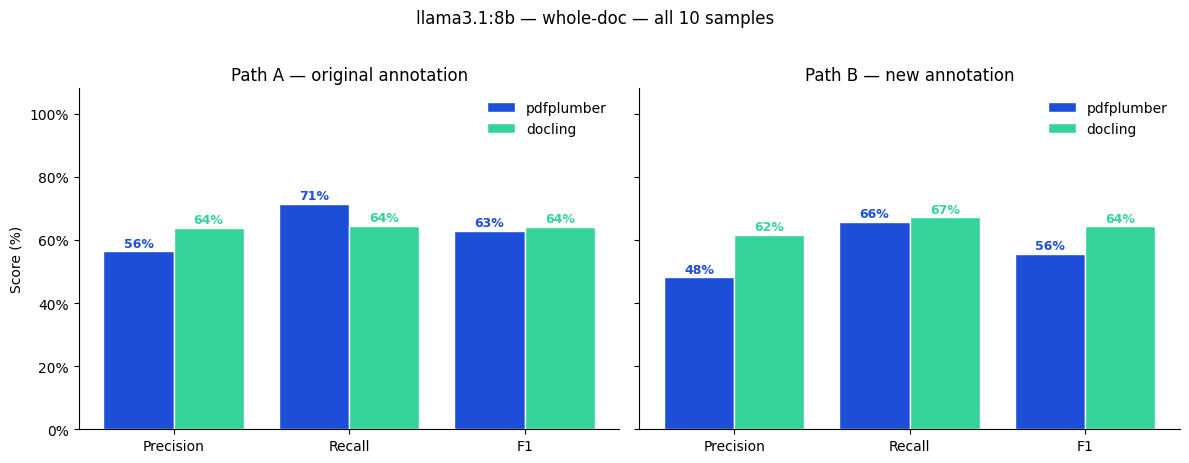

In [3]:
metrics = ["precision", "recall", "f1"]
labels  = ["Precision", "Recall", "F1"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, path in zip(axes, ("A", "B")):
    sub = summary[summary["path"] == path]
    n = len(sub)
    w = 0.8 / max(n, 1)
    for i, (_, r) in enumerate(sub.iterrows()):
        offset = (i - n / 2 + 0.5) * w
        vals = [r[m] for m in metrics]
        bars = ax.bar([x + offset for x in range(len(metrics))], vals, width=w,
                      label=r["extractor"], color=COLORS[r["extractor"]], edgecolor="white")
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f"{v:.0f}%",
                    ha="center", fontsize=9, fontweight="bold", color=COLORS[r["extractor"]])
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 108)
    ax.set_title(f"Path {path} — {'original' if path == 'A' else 'new'} annotation")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(loc="upper right", frameon=False)
axes[0].set_ylabel("Score (%)")
fig.suptitle(f"{MODEL} — whole-doc — all 10 samples", y=1.02, fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

## 2 — Per-label F1

Which of the five labels the model handles well, and which it does not.

label                     pdfplumber · A  pdfplumber · B     docling · A     docling · B  gold items
----------------------------------------------------------------------------------------------------
title                              90.0%           90.0%           70.0%           70.0%          10
section.title                      61.5%           61.0%           70.1%           70.1%          43
section.description                42.1%           42.1%           70.6%           70.6%           8
question.text                      25.0%            7.5%            0.0%           10.8%          18
answer.text                        80.0%           68.3%           78.9%           75.2%          55


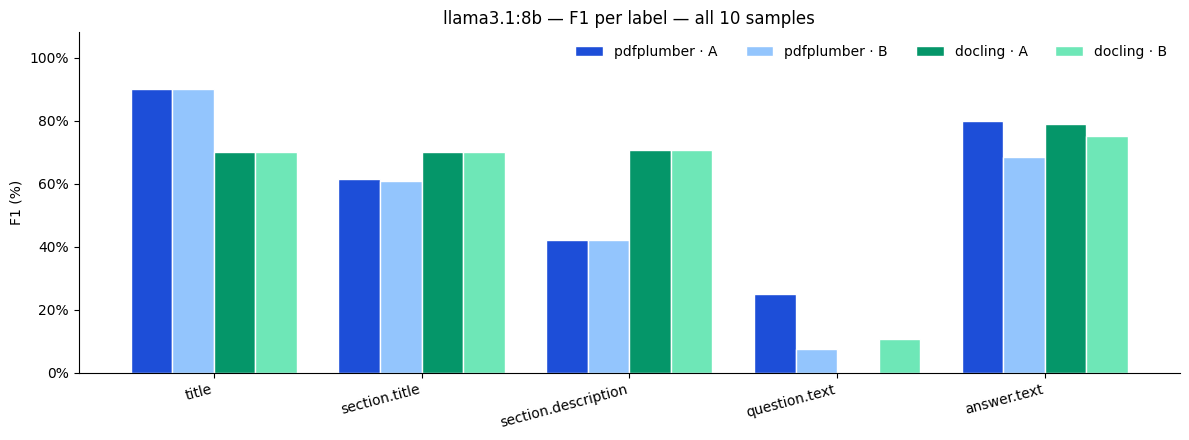

In [4]:
frames = {}
for name, r in results.items():
    for path in ("A", "B"):
        frames[f"{name} · {path}"] = compute_f1_rows(r[path][1]).set_index("label")["f1"] * 100
per_label = pd.DataFrame(frames)

support = compute_f1_rows(list(results.values())[0]["B"][1]).set_index("label")["support"]
print(f"{'label':<24}" + ''.join(f"{c:>16}" for c in per_label.columns) + f"{'gold items':>12}")
print('-' * (24 + 16 * len(per_label.columns) + 12))
for lab, row in per_label.iterrows():
    print(f"{lab:<24}" + ''.join(f"{v:>15.1f}%" for v in row) + f"{support[lab]:>12}")

ax = per_label.plot(kind="bar", figsize=(12, 4.5), width=0.8,
                    color=["#1d4ed8", "#93c5fd", "#059669", "#6ee7b7"], edgecolor="white")
ax.set_ylabel("F1 (%)")
ax.set_xlabel("")
ax.set_ylim(0, 108)
ax.set_title(f"{MODEL} — F1 per label — all 10 samples")
ax.legend(frameon=False, ncol=4)
plt.xticks(rotation=15, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

## 3 — Per-sample accuracy

Where the model is strong and where it struggles, document by document.

sample       pdfplumber       docling
-------------------------------------
1                 67.9%         53.6%
2                 52.0%         52.0%
3                 85.7%        100.0%
4                 66.7%        100.0%
5                 30.8%         69.2%
6                 27.3%         18.2%
7                 33.3%        100.0%
8                 92.3%         76.9%
9                 81.8%        100.0%
10               100.0%         76.9%


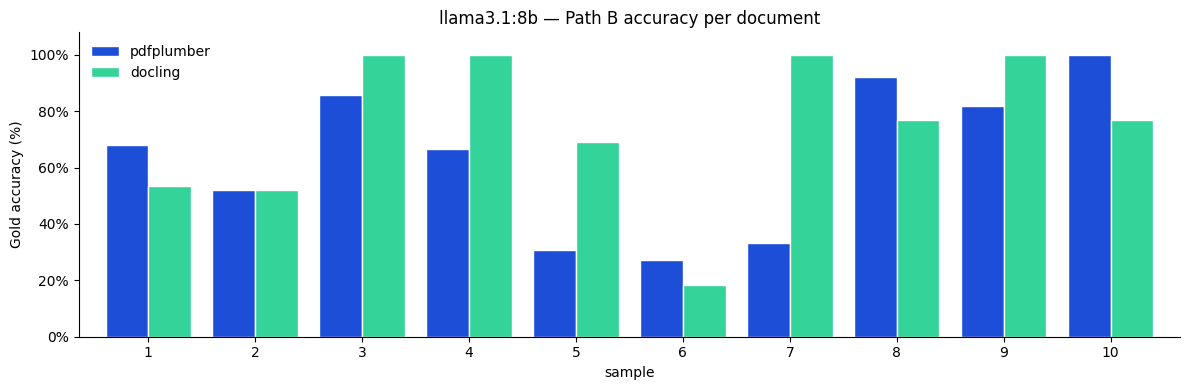

In [5]:
frames = {}
for name, r in results.items():
    df = r["B"][0].set_index("sample")
    frames[name] = df["accuracy"] * 100
per_sample = pd.DataFrame(frames)
per_sample.index = [s.replace("sample", "") for s in per_sample.index]
per_sample = per_sample.loc[sorted(per_sample.index, key=int)]

print(f"{'sample':<9}" + ''.join(f"{c:>14}" for c in per_sample.columns))
print('-' * (9 + 14 * len(per_sample.columns)))
for s, row in per_sample.iterrows():
    print(f"{s:<9}" + ''.join(f"{v:>13.1f}%" for v in row))

ax = per_sample.plot(kind="bar", figsize=(12, 4), width=0.8,
                     color=[COLORS[c] for c in per_sample.columns], edgecolor="white")
ax.set_ylabel("Gold accuracy (%)")
ax.set_xlabel("sample")
ax.set_ylim(0, 108)
ax.set_title(f"{MODEL} — Path B accuracy per document")
ax.legend(frameon=False)
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

## 4 — Confusion matrix

Rows are the true label, columns what the model predicted. Off-diagonal cells are
confusions; the `missed` column counts gold items the model produced nothing for.

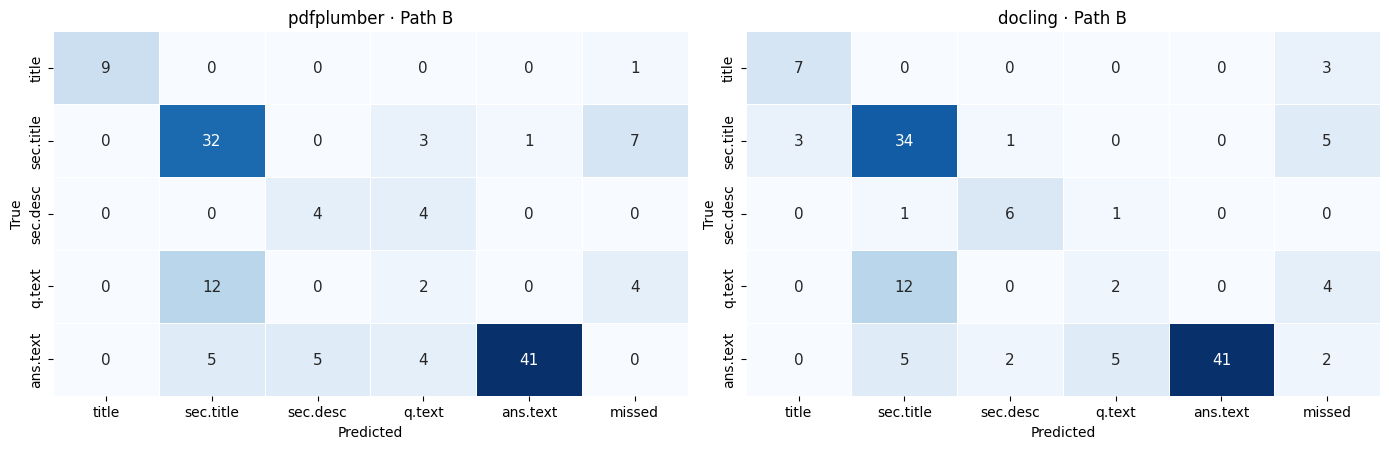

In [6]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 4.6))
if n == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    mat = confusion_matrix_df(r["B"][1])
    sns.heatmap(mat, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
                linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11})
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name} · Path B")
plt.tight_layout()
plt.show()

## 5 — Where it goes wrong

The most common confusions, and a sample of the text involved.

In [7]:
for name, r in results.items():
    err = r["B"][2]
    print(f"===== {name} · Path B — {len(err)} error(s) =====")
    if err.empty:
        print("  (none)\n")
        continue
    counts = err.groupby(["true", "pred"]).size().sort_values(ascending=False)
    print(f"\n  {'true label':<22}{'predicted as':<22}{'count':>6}")
    print('  ' + '-' * 50)
    for (t, p), c in counts.head(8).items():
        print(f"  {t:<22}{p:<22}{c:>6}")
    print(f"\n  examples:")
    for _, e in err.head(5).iterrows():
        print(f"    [{e['sample']}] {e['true']} -> {e['pred']}")
        print(f"        {e['text'][:95]!r}")
    print()

===== pdfplumber · Path B — 95 error(s) =====

  true label            predicted as           count
  --------------------------------------------------
  no_gold_match         answer.text               23
  no_gold_match         question.text             22
  no_gold_match         section.title             13
  question.text         section.title             12
  answer.text           section.description        5
  answer.text           section.title              5
  answer.text           question.text              4
  section.description   question.text              4

  examples:
    [sample1] question.text -> section.title
        'B. Scientific data that will be preserved and shared, and the rationale for doing so:'
    [sample1] question.text -> section.title
        'C. Metadata, other relevant data, and associated documentation:'
    [sample1] answer.text -> question.text
        'The following data will be created as a result of this project:'
    [sample1] question.text -> se

## Notes

- Repeated identical runs of this pipeline have been observed to vary by roughly **3 points of F1**,
  so differences smaller than that should not be read as real.
- Sample 5 will always show errors under Path B: its reference annotation merges several
  sub-questions into one with their answers joined, and no rule in `Rules.xlsx` covers merging.
- These are two of the nine planned configurations (E01–E09). The remaining models and the
  LightOnOCR extractor have not been run under the current pipeline.